# Case Study: Market Analysis
    Name: Nathaniel Ken A. Aquino
    Section: 4CSC
----

### Market basket analysis: a motivating example

Market Basket Analysis is a data mining technique used to discover associations and relationships between items purchased together. The primary goal is to identify patterns of co-occurrence among products in transactions, revealing insights into customer behavior and preferences. This analysis is widely used in retail, e-commerce, and other industries to optimize product placement, promotions, and cross-selling strategies.

#### Key Concepts:

1. Association Rules:
    Market Basket Analysis is often associated with deriving rules of the form "If a customer buys item X, they are likely to buy item Y as well."

2. Support, Confidence, and Lift:
    Support measures how frequently a set of items appears together, confidence measures the likelihood that item Y is bought when item X is bought, and lift indicates the strength of the association between items.

#### Example of Market Basket Analysis in Python:

Let's use a Python example with the mlxtend library to perform Market Basket Analysis on a sample retail dataset:

In [24]:
import warnings

warnings.filterwarnings('ignore')

In [25]:
# Install the mlxtend library if not already installed
# %pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for market basket analysis
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply Apriori algorithm to find frequent itemsets for basket with min. support of 0.2
frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)

# Generate association rules using lift with min threshold = 1
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Display the frequent itemsets and association rules
print("Frequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
print(rules)


Frequent Itemsets:
   support   itemsets
0      1.0        (A)
1      1.0        (B)
2      0.5        (C)
3      1.0     (B, A)
4      0.5     (A, C)
5      0.5     (B, C)
6      0.5  (B, A, C)

Association Rules:
   antecedents consequents  antecedent support  consequent support  support  \
0          (B)         (A)                 1.0                 1.0      1.0   
1          (A)         (B)                 1.0                 1.0      1.0   
2          (A)         (C)                 1.0                 0.5      0.5   
3          (C)         (A)                 0.5                 1.0      0.5   
4          (B)         (C)                 1.0                 0.5      0.5   
5          (C)         (B)                 0.5                 1.0      0.5   
6       (B, A)         (C)                 1.0                 0.5      0.5   
7       (B, C)         (A)                 0.5                 1.0      0.5   
8       (A, C)         (B)                 0.5                 1.0      0.

    In this example, we simulate a retail dataset with transactions and items. The mlxtend library is then used to perform Apriori algorithm-based Market Basket Analysis. The output includes frequent itemsets and association rules, providing insights into which items are frequently purchased together.

### Frequent itemsets, closed itemsets, and association rules

In Market Basket Analysis, the concepts of frequent itemsets, closed itemsets, and association rules play a crucial role in identifying patterns and relationships within transactional data.

#### Key Concepts:

1. Frequent Itemsets:
    A frequent itemset is a set of items that frequently appear together in transactions. It is determined based on a minimum support threshold, which specifies the minimum frequency or percentage of transactions in which the itemset should occur.

2. Closed Itemsets:
    A closed itemset is a frequent itemset for which none of its supersets have the same support. In other words, it is an itemset that is not a subset of any other frequent itemset with the same support. Closed itemsets provide a more compact representation of frequent patterns.

3. Association Rules:
    Association rules express relationships between items in the form of "if item X is present, then item Y is likely to be present as well." These rules are derived from frequent itemsets and are characterized by metrics such as confidence and lift.

#### Example of Frequent Itemsets, Closed Itemsets, and Association Rules in Python:

Let's use the mlxtend library to demonstrate these concepts on a sample dataset:

In [26]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for frequent itemset mining
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply Apriori algorithm to find frequent itemsets with min. support 20%
frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)

# Find closed itemsets
closed_itemsets = frequent_itemsets[frequent_itemsets['support'] == frequent_itemsets['support']]

# Generate association rules with min threshold of 0.7 using confidence
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Display the frequent itemsets, closed itemsets, and association rules
print("Frequent Itemsets:")
print(frequent_itemsets)

print("\nClosed Itemsets:")
print(closed_itemsets)

print("\nAssociation Rules:")
print(rules)


Frequent Itemsets:
   support   itemsets
0      1.0        (A)
1      1.0        (B)
2      0.5        (C)
3      1.0     (B, A)
4      0.5     (A, C)
5      0.5     (B, C)
6      0.5  (B, A, C)

Closed Itemsets:
   support   itemsets
0      1.0        (A)
1      1.0        (B)
2      0.5        (C)
3      1.0     (B, A)
4      0.5     (A, C)
5      0.5     (B, C)
6      0.5  (B, A, C)

Association Rules:
  antecedents consequents  antecedent support  consequent support  support  \
0         (B)         (A)                 1.0                 1.0      1.0   
1         (A)         (B)                 1.0                 1.0      1.0   
2         (C)         (A)                 0.5                 1.0      0.5   
3         (C)         (B)                 0.5                 1.0      0.5   
4      (B, C)         (A)                 0.5                 1.0      0.5   
5      (A, C)         (B)                 0.5                 1.0      0.5   
6         (C)      (B, A)                 0.5

    In this example, we use the mlxtend library to find frequent itemsets, closed itemsets, and association rules from a simulated retail dataset. The output includes sets of items that frequently occur together (frequent itemsets), closed itemsets that are not part of larger frequent itemsets with the same support, and association rules indicating relationships between items.

### Apriori Algorithm: Finding Frequent Itemsets by Confined Candidate Generation

The Apriori algorithm is a classic data mining algorithm used for discovering frequent itemsets in transactional datasets. It employs a level-wise approach to explore combinations of items and efficiently identifies those that meet a specified support threshold. The algorithm uses the Apriori property, which states that if an itemset is frequent, all of its subsets must also be frequent.

#### Key Steps of the Apriori Algorithm:

1. Candidate Generation:
    The algorithm starts with individual items as candidates and iteratively generates larger candidate itemsets based on the frequent itemsets discovered in the previous iteration.

2. Support Counting:
    The support of each candidate itemset is calculated by counting the number of transactions containing the itemset.

3. Pruning:
    Itemsets with support below a predefined threshold are pruned, as they cannot be part of frequent itemsets.

4. Iteration:
    The process iterates until no new frequent itemsets can be generated.

#### Example of Apriori Algorithm in Python:

Let's use the mlxtend library to implement the Apriori algorithm on a sample retail dataset:

In [27]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for Apriori algorithm
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply Apriori algorithm to find frequent itemsets with min support 20%
frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)

# Display the frequent itemsets
print("Frequent Itemsets:")
print(frequent_itemsets)


Frequent Itemsets:
   support   itemsets
0      1.0        (A)
1      1.0        (B)
2      0.5        (C)
3      1.0     (B, A)
4      0.5     (A, C)
5      0.5     (B, C)
6      0.5  (B, A, C)


    In this example, the Apriori algorithm is applied to find frequent itemsets in a retail dataset. The mlxtend library's apriori function is used to generate itemsets based on a minimum support threshold.

### Generating association rules from frequent itemsets

Once frequent itemsets have been identified using algorithms like Apriori, the next step in Market Basket Analysis is to generate association rules. Association rules reveal interesting relationships between items in the dataset, providing valuable insights for businesses to make informed decisions about product placement, marketing strategies, and cross-selling.

#### Key Concepts:

1. Support, Confidence, and Lift:
    These metrics are used to evaluate the strength and significance of association rules.
    
        Support: Measures the frequency of occurrence of an itemset.

        Confidence: Measures the likelihood that item Y is bought when item X is bought.
        
        Lift: Indicates the strength of the association between items.

2. Association Rule Format:

        Association rules are typically represented as "if X, then Y," where X and Y are itemsets.

#### Example of Generating Association Rules in Python:

Let's continue with the previous example and use the mlxtend library to generate association rules from the frequent itemsets:

In [28]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for Apriori algorithm
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply Apriori algorithm to find frequent itemsets with min_support 0.2
frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)

# Generate association rules with min threshold 0.7 using confidence metric
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Display the association rules
print("Association Rules:")
print(rules)


Association Rules:
  antecedents consequents  antecedent support  consequent support  support  \
0         (B)         (A)                 1.0                 1.0      1.0   
1         (A)         (B)                 1.0                 1.0      1.0   
2         (C)         (A)                 0.5                 1.0      0.5   
3         (C)         (B)                 0.5                 1.0      0.5   
4      (B, C)         (A)                 0.5                 1.0      0.5   
5      (A, C)         (B)                 0.5                 1.0      0.5   
6         (C)      (B, A)                 0.5                 1.0      0.5   

   confidence  lift  representativity  leverage  conviction  zhangs_metric  \
0         1.0   1.0               1.0       0.0         inf            0.0   
1         1.0   1.0               1.0       0.0         inf            0.0   
2         1.0   1.0               1.0       0.0         inf            0.0   
3         1.0   1.0               1.0       

    In this example, after obtaining the frequent itemsets, the mlxtend library's association_rules function is used to generate association rules based on a confidence threshold. The output includes rules with information about antecedent (if) and consequent (then) itemsets, as well as metrics like support, confidence, and lift.

### Improving the efficiency of Apriori

The Apriori algorithm is a powerful tool for finding frequent itemsets and generating association rules, but it can become computationally expensive, especially for large datasets. Several techniques can be applied to improve the efficiency of the Apriori algorithm.

#### Key Strategies for Efficiency Improvement:

1. Pruning Strategies:
        Implementing strategies such as the "hash-based" or "tree-based" pruning can help reduce the search space by avoiding the generation of candidate itemsets that are known to be infrequent.

2. Transaction Reduction:
        Reducing the size of transactions or considering a smaller sample of transactions can significantly speed up the Apriori algorithm.

3. Parallelization:
        Distributing the workload across multiple processors or nodes can lead to a substantial improvement in performance, especially for datasets with a large number of transactions.

4. Dynamic Itemset Counting:
        Dynamically adjusting the minimum support threshold based on the size of the dataset or the progress of the algorithm can optimize the search for frequent itemsets.

#### Example of Efficiency Improvement in Apriori Algorithm in Python:

Let's demonstrate a simple example of how to parallelize the Apriori algorithm using the mlxtend library in Python:

In [29]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from joblib import Parallel, delayed

# Simulate a large retail dataset
data = {
    'TransactionID': [i for i in range(1, 10001)],
    'Item': ['A', 'B', 'C', 'D', 'E'] * 2000
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for parallelized Apriori algorithm
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply parallelized Apriori algorithm to find frequent itemsets with min support of 0.2 use n_jobs =-1
# frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True, n_jobs=-1) # Alternatively, we can just remove the syntax for n_jobs=-1 since mlxtend does not support n_jobs
def apriori_subset(subset):
    return apriori(subset, min_support=0.2, use_colnames=True)

# Split the dataset into chunks for parallel processing
num_chunks = 4
chunks = [basket.iloc[i::num_chunks, :] for i in range(num_chunks)]

# Run Apriori in parallel across chunks
results = Parallel(n_jobs=-1)(delayed(apriori_subset)(chunk) for chunk in chunks)

# Combine and remove duplicates
frequent_itemsets = pd.concat(results).drop_duplicates()

# Display the frequent itemsets
print("Frequent Itemsets:")
print(frequent_itemsets)


Frequent Itemsets:
   support itemsets
0      0.2      (A)
1      0.2      (B)
2      0.2      (C)
3      0.2      (D)
4      0.2      (E)


    In this example, the n_jobs=-1 parameter in the apriori function instructs the algorithm to use all available processors for parallelization. This can significantly improve the efficiency of the Apriori algorithm, especially when dealing with large datasets.

### A pattern-growth approach for mining frequent itemsets

A pattern-growth approach is an alternative strategy for mining frequent itemsets that differs from the traditional Apriori algorithm. Instead of candidate generation and pruning, the pattern-growth approach grows frequent itemsets from smaller ones by leveraging a compact data structure called a prefix tree or FP-tree. This approach can be more memory-efficient and faster, particularly for datasets with a large number of transactions.

#### Key Steps in a Pattern-Growth Approach:

1. Constructing the FP-Tree:
        Build a compact data structure, the FP-tree, from the transaction dataset. The FP-tree efficiently represents the frequency of itemsets.

2. Mining Frequent Itemsets:
        Use recursive techniques to mine frequent itemsets directly from the FP-tree without generating candidate itemsets explicitly.

3. Conditional Pattern Base:
        Utilize a conditional pattern base to find frequent itemsets in a more targeted and efficient manner.

#### Example of Pattern-Growth Approach in Python:

Let's use the mlxtend library to implement the FP-growth algorithm on a sample retail dataset:

In [30]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for FP-growth
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply FP-growth algorithm to find frequent itemsets
frequent_itemsets = fpgrowth(basket, min_support=0.2, use_colnames=True)

# Display the frequent itemsets
print("Frequent Itemsets:")
print(frequent_itemsets)


Frequent Itemsets:
   support   itemsets
0      1.0        (B)
1      1.0        (A)
2      0.5        (C)
3      1.0     (B, A)
4      0.5     (B, C)
5      0.5     (A, C)
6      0.5  (B, A, C)


    In this example, the FP-growth algorithm from the mlxtend library is applied to find frequent itemsets in a retail dataset. The fpgrowth function generates itemsets directly without the need for candidate generation and pruning, making it a pattern-growth approach.

### Mining frequent itemsets using the vertical data format

Mining frequent itemsets can be approached using the vertical data format, an alternative representation of transactional data. In this format, each record corresponds to a unique item and its associated transactions. This approach can be particularly useful when dealing with high-dimensional datasets where the number of distinct items is large.

#### Key Concepts:

1. Vertical Data Format:
    In the vertical data format, each item and its corresponding transactions are stored together. This format simplifies the process of identifying frequent itemsets by focusing on each item independently.

2. Transaction Identifier Lists:
    For each item, a list of transaction identifiers is maintained, indicating in which transactions the item occurs. This allows for efficient counting of support for each item.

3. Inverse Transaction Mapping:
    In addition to lists of transaction identifiers for each item, an inverse mapping is often used to retrieve the items associated with a given transaction efficiently.

#### Example of Mining Frequent Itemsets in Vertical Data Format in Python:

Let's use the mlxtend library to demonstrate mining frequent itemsets using the vertical data format on a sample retail dataset:

In [31]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Simulate a retail dataset in vertical format
data = {
    'TransactionID': [1, 2, 3, 4, 5],
    'Items': [['A', 'B', 'D'], ['A', 'C', 'D'], ['B', 'D'], ['A', 'B', 'C'], ['A', 'C']]
}

df = pd.DataFrame(data)

# Convert data to the horizontal format using TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(df['Items']).transform(df['Items'])
horizontal_df = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(horizontal_df, min_support=0.2, use_colnames=True)

# Display the frequent itemsets
print("Frequent Itemsets:")
print(frequent_itemsets)


Frequent Itemsets:
    support   itemsets
0       0.8        (A)
1       0.6        (B)
2       0.6        (C)
3       0.6        (D)
4       0.4     (B, A)
5       0.6     (A, C)
6       0.4     (A, D)
7       0.2     (B, C)
8       0.4     (B, D)
9       0.2     (D, C)
10      0.2  (B, A, C)
11      0.2  (B, A, D)
12      0.2  (A, D, C)


    In this example, the dataset is represented in the vertical format, and the TransactionEncoder from the mlxtend library is used to convert it to the horizontal format. The Apriori algorithm is then applied to find frequent itemsets.

### Mining closed and max patterns

In data mining, beyond finding frequent itemsets, there is interest in discovering closed and max patterns. These patterns provide more concise and specific information about frequent itemsets, aiding in the interpretation and application of mining results.

#### Key Concepts:

1. Closed Patterns:
    Closed patterns are frequent itemsets that cannot be extended by adding any more items without decreasing their support. These patterns offer a compact representation of frequent itemsets by eliminating redundant combinations.

2. Max Patterns:
    Max patterns are the largest frequent itemsets in terms of support and are not subsumed by any other frequent itemset. Max patterns provide a more condensed and focused view of the most significant patterns in the dataset.

#### Example of Mining Closed and Max Patterns in Python:

Let's use the mlxtend library to mine closed and max patterns from a sample retail dataset:

In [32]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for FP-growth
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply FP-growth algorithm to find frequent itemsets min_support 0.2
frequent_itemsets = fpgrowth(basket, min_support=0.2, use_colnames=True)

# Generate closed patterns
closed_patterns = frequent_itemsets.groupby('itemsets')['support'].max().reset_index()

# Generate max patterns. Hint use groupby and (first occurrence of the) maximum value
max_patterns = frequent_itemsets.groupby('itemsets')['support'].idxmax()
max_patterns = frequent_itemsets.loc[max_patterns]

# Display the closed and max patterns
print("Closed Patterns:")
print(closed_patterns)

print("\nMax Patterns:")
print(max_patterns)


Closed Patterns:
    itemsets  support
0        (B)      1.0
1        (A)      1.0
2        (C)      0.5
3     (B, A)      1.0
4     (B, C)      0.5
5     (A, C)      0.5
6  (B, A, C)      0.5

Max Patterns:
   support   itemsets
0      1.0        (B)
1      1.0        (A)
2      0.5        (C)
3      1.0     (B, A)
4      0.5     (B, C)
5      0.5     (A, C)
6      0.5  (B, A, C)


    In this example, after finding frequent itemsets using the FP-growth algorithm, closed patterns are identified by selecting itemsets with support equal to their own support. Max patterns are determined by selecting the itemsets with the maximum support for each set of items.

### Strong rules are not necessarily interesting

In the context of association rule mining, it's important to understand that strong rules, determined by metrics like confidence and lift, are not always inherently interesting or valuable. While these metrics quantify the strength and significance of association rules, they may not capture the real-world relevance or usefulness of the discovered patterns.

#### Key Concepts:

1. Confidence and Lift:

    Confidence measures the likelihood that item Y is purchased given the purchase of item X.

    Lift measures the strength of the association between items, considering the independence of X and Y.

2. Interest and Context:

    Strong rules may have high confidence and lift but lack practical significance or actionable insights in a specific context.

    The interpretation and usefulness of rules depend on the domain and the goals of the data mining process.


#### Example of Strong Rules Not Being Interesting in Python:

Let's use the mlxtend library to demonstrate the concept of strong rules that may not be interesting in a practical context:

In [33]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for Apriori algorithm
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.7)

# Display the association rules
print("Association Rules:")
print(rules)


Association Rules:
  antecedents consequents  antecedent support  consequent support  support  \
0         (B)         (A)                 1.0                 1.0      1.0   
1         (A)         (B)                 1.0                 1.0      1.0   
2         (C)         (A)                 0.5                 1.0      0.5   
3         (C)         (B)                 0.5                 1.0      0.5   
4      (B, C)         (A)                 0.5                 1.0      0.5   
5      (A, C)         (B)                 0.5                 1.0      0.5   
6         (C)      (B, A)                 0.5                 1.0      0.5   

   confidence  lift  representativity  leverage  conviction  zhangs_metric  \
0         1.0   1.0               1.0       0.0         inf            0.0   
1         1.0   1.0               1.0       0.0         inf            0.0   
2         1.0   1.0               1.0       0.0         inf            0.0   
3         1.0   1.0               1.0       

    In this example, association rules are generated using the Apriori algorithm, and rules with a confidence threshold of 0.7 are selected. However, it's crucial to emphasize to students that high confidence alone does not guarantee the real-world relevance or interestingness of a rule. The interpretation and application of rules should be considered in the specific context of the data and business domain.

### From association analysis to correlation analysis

Association analysis and correlation analysis are two related but distinct techniques in data mining. While association analysis focuses on discovering relationships between items or variables, correlation analysis quantifies the strength and direction of a linear relationship between two numeric variables.

#### Key Concepts:

1. Association Analysis:

    Association analysis is concerned with finding interesting patterns or relationships in large datasets.

    It often deals with categorical data and aims to discover rules indicating co-occurrence or sequence patterns.

2. Correlation Analysis:

    Correlation analysis, on the other hand, is used for numeric variables.

    It measures the strength and direction of a linear relationship between two variables, expressed as the correlation coefficient.

3. Pearson Correlation Coefficient:

    The Pearson correlation coefficient ranges from -1 to 1, where:

        1 indicates a perfect positive linear relationship,

        -1 indicates a perfect negative linear relationship, and
        
        0 indicates no linear relationship.

#### Example of Moving from Association Analysis to Correlation Analysis in Python:

Let's use a dataset with numeric variables to illustrate the transition from association analysis to correlation analysis in Python:

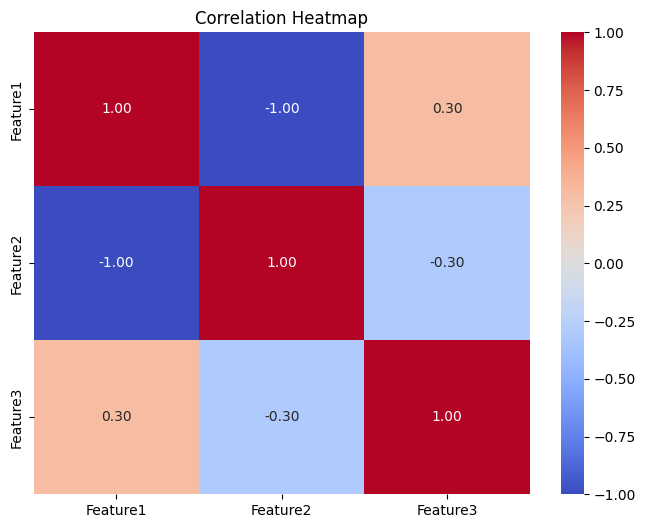

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Simulate a dataset with numeric variables
data = {
    'Feature1': [1, 2, 3, 4, 5],
    'Feature2': [5, 4, 3, 2, 1],
    'Feature3': [2, 4, 1, 5, 3]
}

df = pd.DataFrame(data)

# Visualize the dataset using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

    In this example, we create a dataset with three numeric features. We then use the Seaborn library to generate a heatmap illustrating the Pearson correlation coefficients between these features.

    That while association analysis might involve discovering rules like "if Feature1=3, then Feature2=3," correlation analysis quantifies the degree and direction of the linear relationship between Feature1 and Feature2. Emphasize the interpretation of correlation coefficients and how they can provide insights into the strength and nature of relationships between numeric variables.

### A comparison of pattern evaluation measures

I'm writing notebooks for Data Mining concept and techniques as teacher assistant. Help me with a short explanation on 
4.3.3. A comparison of pattern evaluation measures
And a real world example of practical use in python for it to put in notebook.

#### Key Concepts:

1. Support:
    Support measures the frequency of occurrence of a pattern in the dataset. It is the proportion of transactions that contain the pattern.

2. Confidence:
    Confidence quantifies the strength of an association rule. It is the conditional probability of the consequent given the antecedent.

3. Lift:
    Lift assesses the significance of an association rule by comparing the observed support of the rule to what would be expected if the antecedent and consequent were independent.

4. Conviction:
    Conviction measures the degree of implication between the antecedent and consequent in a rule. It indicates how much more likely the consequent is if the antecedent is true.

#### Example of Comparing Pattern Evaluation Measures in Python:

Let's use a sample retail dataset to demonstrate the calculation of support, confidence, lift, and conviction for association rules in Python:

In [35]:
# Install the mlxtend library if not already installed
# pip install mlxtend

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Simulate a retail dataset
data = {
    'TransactionID': [1, 1, 2, 2, 3, 3, 3, 4, 4, 4],
    'Item': ['A', 'B', 'A', 'B', 'A', 'B', 'C', 'A', 'B', 'C']
}

df = pd.DataFrame(data)

# Perform one-hot encoding to prepare data for Apriori algorithm. Hint: Use crosstab
basket = pd.crosstab(index=df['TransactionID'], columns=df['Item']).applymap(lambda x: 1 if x > 0 else 0)

# Apply Apriori algorithm to find frequent itemsets. Min support 20%
frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)

# Generate association rules. Use confidence metrics , min threshold 0.7
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.7)

# Display the rules with support, confidence, lift, and conviction
print("Association Rules with Evaluation Measures:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction']])


Association Rules with Evaluation Measures:
  antecedents consequents  support  confidence  lift  conviction
0         (B)         (A)      1.0         1.0   1.0         inf
1         (A)         (B)      1.0         1.0   1.0         inf
2         (C)         (A)      0.5         1.0   1.0         inf
3         (C)         (B)      0.5         1.0   1.0         inf
4      (B, C)         (A)      0.5         1.0   1.0         inf
5      (A, C)         (B)      0.5         1.0   1.0         inf
6         (C)      (B, A)      0.5         1.0   1.0         inf


    In this example, association rules are generated using the Apriori algorithm, and evaluation measures such as support, confidence, lift, and conviction are calculated for each rule. This allows for a comparison of the different measures and their implications for rule quality.

----

# Questions
1. What is Market Basket Analysis, and why is it useful in retail and e-commerce?

2. Explain association rules in Market Basket Analysis with an example.

3. Define support, confidence, and lift in the context of Market Basket Analysis. How do these metrics help evaluate association rules?

4. How can businesses use Market Basket Analysis to optimize product placement and promotions?

5. What are some real-world applications of Market Basket Analysis beyond retail?

# Answers

1. Market Basket Analysis allows for the analysis of the hidden patterns and relationships between and within the data/items purchased. It shows which items are currently bought together and gives the seller insights on which items should be grouped together to promote their sales.

2. Association rules are using in Market Basket Analysis as it is a method in which we identify which items/products are most likely correlated or bought together with another product. An example for this could be in a restaurant. Let's say Jollibee for example, wherein we can identify that when a customer buys a burger, they would also most likely buy it with fries and with drinks, or if they bought a chickenjoy, they would also include a peach mango pie in their order.

3. 
- **Support** — measures how often or how frequently certain items appear together per transaction.
- **Confidence** — measures using the question "out of all the items, how often are the items together, " or the probability that these items appear together in the whole dataset.
- **Lift** — measures the strength of the association between the items or how much more likely the consequent is bought when the antecedent is also bought in comparison with when the items appear individually.

These metrics help evaluate association rules as we can see which items or set of items appear to have the most interesting insights to be given to the company and we can use these measures to identify the most actionable rules out of all associations

4. Business can use Market Basket Analysis in which they can entice customers to buy bundles of a specific product or to group the products in a specific way in which customers are more likely to grab these items together. One scenario is at a grocery store wherein the products are placed strategically from each other, with products with the strongest association being more likely to be placed with each other. Another scenario is promoting some products using a 'bundle' wherein when you purchase a specific product, it comes with the associated product which can help with marketing.

5. Beyond retail, Market Basket Analysis can be used in the Manufacturing business wherein we can collect data on their status when items are being manufactured and we can find patterns that, when they happen together or if the symptoms appear together, are most likely to appear to be defective. Alternatively, we can also use these for experiments wherein we can identify which patterns could yield better results.

# END
----